# Exploration of influence of cycling on ASHP performance
This builds some simple decision trees to see whether the cycling features can help diagnose causes for under performance. The models built here are not intended for actual deployment, but to aid understanding of performance in the EoH trial.

The core finding is that a simple method of detecting cycles does a reasonable job of helping group heat pumps into intuitive categories (e.g. long cycles, low flow temperatures) that go some way to separating out causes of poor performance. Unsurprisingly, the best performing heat pumps have long cycles at low flow temperatures with only short gaps between them.

I think a good next step would be to explicitly build (probably rule-based) features designed to detect:
- low flow temperatures but cycles are shortened because the heat pump can't operate at low enough power (oversized heat pump or min flow temperature needs raising)
- seperating out "high constant flow temp" from "ramping up flow temp" and using those to recommend an action when cycles are short and gaps are long (though do they have the same action - adjust weather compensation curve?)
- identifying high flow temp, long-ish cycle, short gap heat pumps, as these probably can't just tweak the flow temp

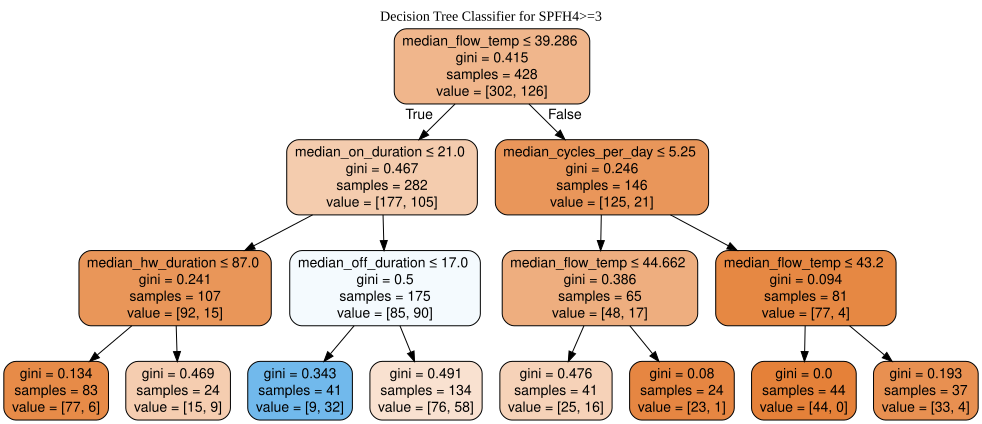

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
import graphviz

# Input data is all ASHPs that were included in the original EoH analysis, with cycling features calculated
homes_with_features = pd.read_csv("homes_with_features.csv")

# Define "Good" performance as SPFH4 >= 3
homes_with_features["Good_Performance"] = homes_with_features["SPFH4_selected_window"] >= 3
target = "Good_Performance"
target_values = homes_with_features[target]

# Drop columns that are uniquely identifying / confounding, or variables we don't want in the model
# You can experiment with different variations, but I found this gave me the most explainable outputs
features = homes_with_features.drop(columns=[target, 
                                             "Property_ID", 
                                             "SPFH4_selected_window",                                             
                                             "HP_Installed",
                                             "HP_Brand",                                             
                                             "HP_Model", 
                                             "HP_Refrigerant",
                                             "HP_Size_kW",
                                             "mean_power", 
                                             ])
categorical_cols = features.select_dtypes(include=['object', 'category']).columns
features = pd.get_dummies(features, columns=categorical_cols, drop_first=True)

# Note: If doing this properly to get a model we'd deploy, then we would do a test-train split 
# or cross validation to ensure that we're not overfitting to the data. Since we're just doing
# this for data exploration to understand potential causes of poor performance, rather than to
# actually predict whether it is performing well or not, we include all properties.
# That does mean we need to be careful about building trees that are too deep - those are more
# likely to be overfitting.

# Initializing and training the Decision Tree Classifier
tree_classifier = DecisionTreeClassifier(random_state=4, max_depth=3, min_samples_leaf=20)
tree_classifier.fit(features, target_values)

# Export the tree to Graphviz format
dot_data = export_graphviz(tree_classifier, out_file=None, 
                           feature_names=features.columns,  
                           filled=True, rounded=True,  
                           special_characters=True)
# Add a title manually by inserting a 'graph' property
dot_data = dot_data.replace("digraph Tree {", 'digraph Tree {\nlabel="Decision Tree Classifier for SPFH4>=3";\nlabelloc="t";')
graph = graphviz.Source(dot_data)
graph.render("Decision Tree Classifier", format="png")
graph

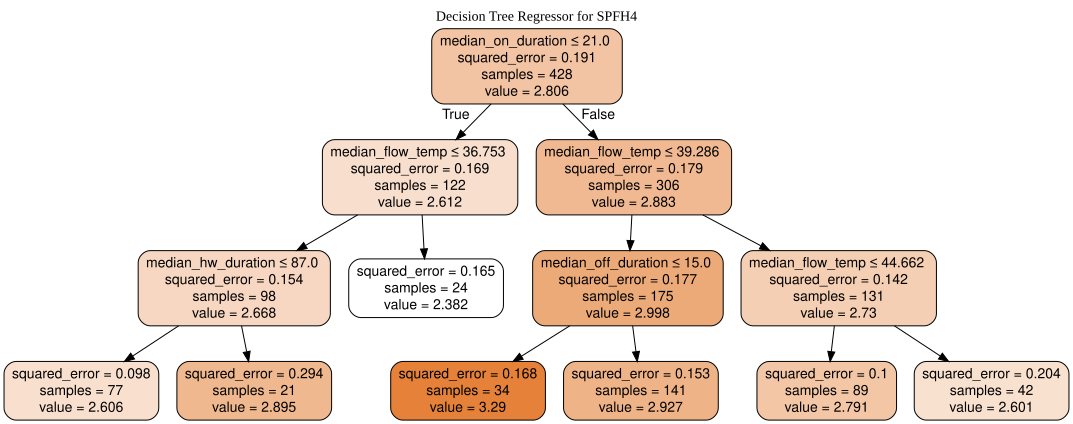

In [2]:
# Initializing and training the Decision Tree Regressor
regression_target = "SPFH4_selected_window"
regression_target_values = homes_with_features[regression_target]

# Note: If doing this properly to get a model we'd deploy, then we would do a test-train split 
# or cross validation to ensure that we're not overfitting to the data. Since we're just doing
# this for data exploration to understand potential causes of poor performance, rather than to
# actually predict whether it is performing well or not, we include all properties.
# That does mean we need to be careful about building trees that are too deep - those are more
# likely to be overfitting.

tree_regressor = DecisionTreeRegressor(random_state=4, max_depth=3, min_samples_leaf=20)
tree_regressor.fit(features, regression_target_values)

# Export the tree to Graphviz format
dot_data_reg = export_graphviz(tree_regressor, out_file=None, 
                           feature_names=features.columns,  
                           filled=True, rounded=True,  
                           special_characters=True)
# Add a title manually by inserting a 'graph' property
dot_data_reg = dot_data_reg.replace("digraph Tree {", 'digraph Tree {\nlabel="Decision Tree Regressor for SPFH4";\nlabelloc="t";')

# Create and display the graph
graph_reg = graphviz.Source(dot_data_reg)
graph.render("Decision Tree Regressor", format="png")
graph_reg

In [3]:
groups = homes_with_features.copy()
groups["Group"] = None

# The better performing heat pumps - long periods at lower flow temperatures
groups.loc[(groups["median_on_duration"] > 21)
           & (groups["median_flow_temp"] < 39.3)
           & (groups["median_off_duration"] <= 15), "Group"] = "Long cycles at low temperature, short gaps"
groups.loc[(groups["median_on_duration"] > 21)
           & (groups["median_flow_temp"] < 39.3)
           & (groups["median_off_duration"] > 15), "Group"] = "Long cycles at low temperature, longer gaps"

# Shorter cycles
groups.loc[(groups["median_on_duration"] <= 21)
           & (groups["median_flow_temp"] >= 36.75), "Group"] = "Short cycles at high temperature"
groups.loc[(groups["median_on_duration"] <= 21)
           & (groups["median_flow_temp"] < 36.75)
           & (groups["median_hw_duration"] > 87), "Group"] = "Short cycles at low temperature with shorter hot water"
groups.loc[(groups["median_on_duration"] <= 21)
           & (groups["median_flow_temp"] < 36.75)
           & (groups["median_hw_duration"] <= 87), "Group"] = "Short cycles at low temperature with longer hot water"

# Longer cycles at higher temperatures
groups.loc[(groups["median_on_duration"] > 21)
           & (groups["median_flow_temp"] >= 39.3), "Group"] = "Long cycles at higher temperatures"

In [4]:
groups.groupby("Group").agg(count=("Property_ID", "count"),
                            median_spfh4=("SPFH4_selected_window", "median"),
                            pct_with_spfh4_gt_3=("Good_Performance", "mean"))

,count,median_spfh4,pct_with_spfh4_gt_3
Group,,,
Long cycles at higher temperatures,130,2.710,0.161538
"Long cycles at low temperature, longer gaps",142,2.947,0.443662
"Long cycles at low temperature, short gaps",34,3.259,0.794118
Short cycles at high temperature,24,2.394,0.041667
Short cycles at low temperature with longer hot water,77,2.654,0.077922
Short cycles at low temperature with shorter hot water,21,2.808,0.380952
